# Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split

# Load and Explore the Dataset

In [2]:
df=pd.read_csv('Housing.csv')

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.shape

(545, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [8]:
df.bedrooms.unique()

array([4, 3, 5, 2, 6, 1])

In [9]:
df.bathrooms.unique()

array([2, 4, 1, 3])

In [10]:
df.bedrooms.unique()

array([4, 3, 5, 2, 6, 1])

In [11]:
df.parking.unique()

array([2, 3, 0, 1])

# Check for infinite values and replace with NaN

In [12]:
df.replace([np.inf,-np.inf],np.nan,inplace=True)

# Drop rows with NaN values

In [13]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

# Set the asthetic style of the plots 

In [14]:
sns.set_style('whitegrid')

# Scatter Plot for Price vs Area

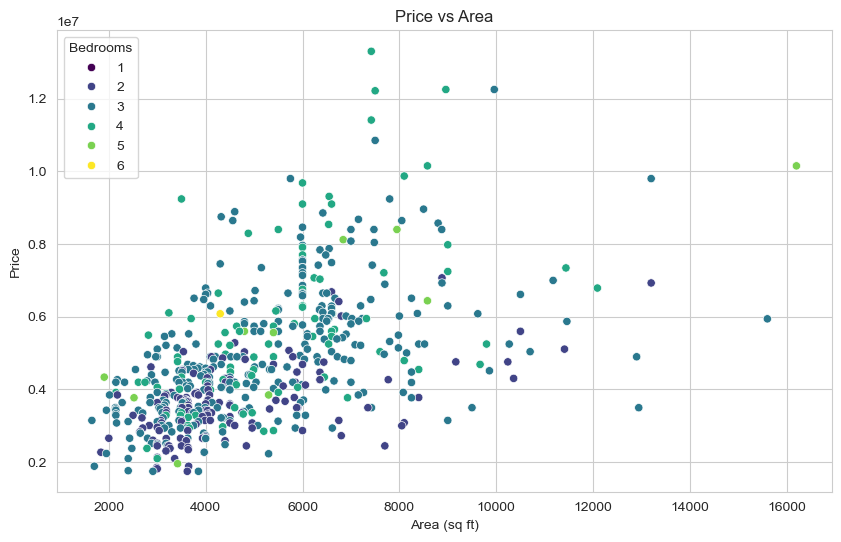

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='area',y='price', data=df,hue='bedrooms', palette='viridis')
plt.title('Price vs Area')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.legend(title='Bedrooms')
plt.show()

# Distibution Plot of price

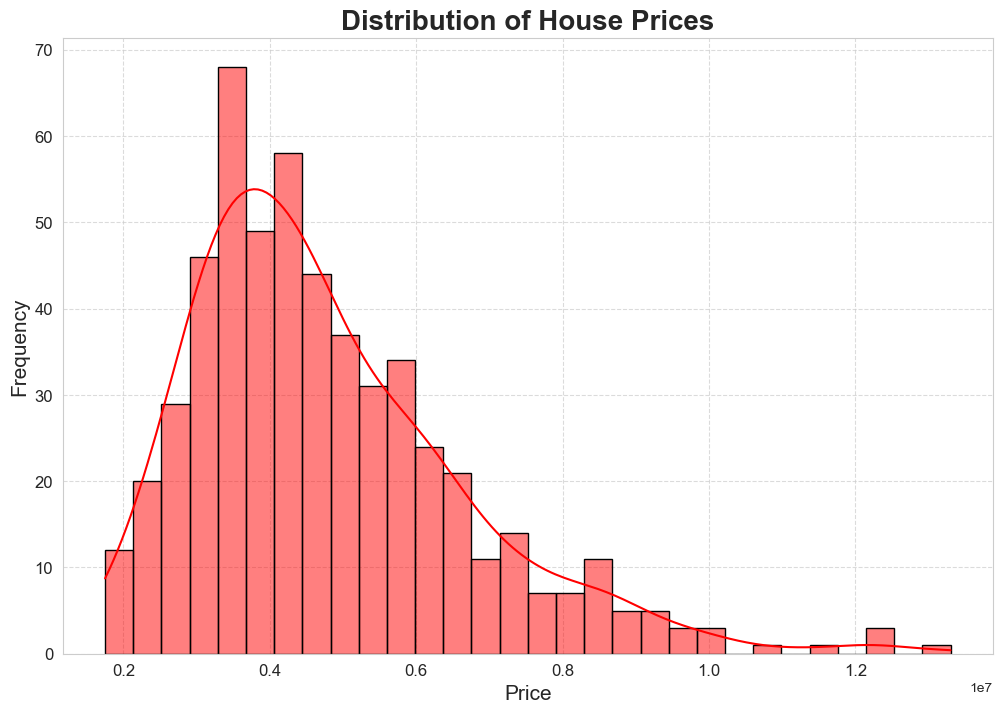

In [16]:
plt.figure(figsize=(12,8))
sns.histplot(df['price'],bins=30,kde=True,color='red',edgecolor='black')
plt.title('Distribution of House Prices', fontsize=20, weight='bold')
plt.xlabel('Price', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

#Adding a grid
plt.grid(True, linestyle='--',alpha=0.7)

#Display the plot
plt.show()

# Count Plot of bedrooms

C:\Users\kasio\AppData\Local\Temp\ipykernel_17328\547707704.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='bedrooms',data=df,palette='viridis')


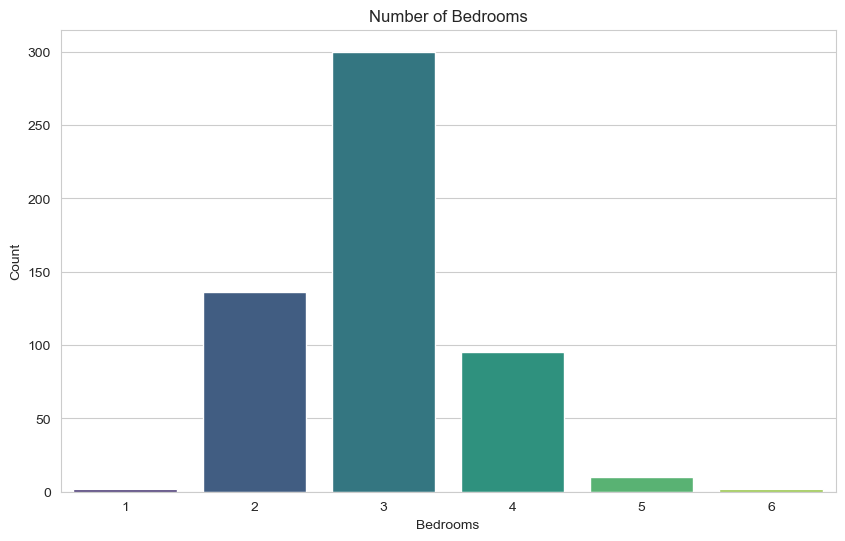

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(x='bedrooms',data=df,palette='viridis')
plt.title('Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Count')
plt.show()

# Count plot of Bathrooms

C:\Users\kasio\AppData\Local\Temp\ipykernel_17328\875169882.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='bathrooms',data=df,palette='viridis')


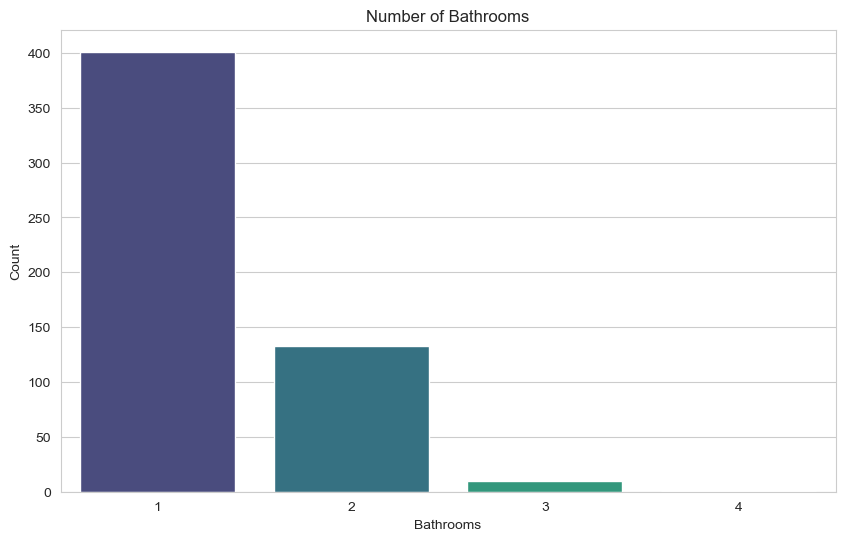

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(x='bathrooms',data=df,palette='viridis')
plt.title('Number of Bathrooms')
plt.xlabel('Bathrooms')
plt.ylabel('Count')
plt.show()

In [19]:
df=df[['price','area','bedrooms','bathrooms']]
df

,price,area,bedrooms,bathrooms
0,13300000,7420,4,2
1,12250000,8960,4,4
2,12250000,9960,3,2
3,12215000,7500,4,2
4,11410000,7420,4,1
...,...,...,...,...
540,1820000,3000,2,1
541,1767150,2400,3,1
542,1750000,3620,2,1
543,1750000,2910,3,1


# Creating dependent and independent varibales

In [20]:
x=df[['area','bathrooms','bedrooms']]
y=df['price']

In [21]:
x.shape,y.shape

((545, 3), (545,))

# Splitting the dataset into training and testing sets

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Initializing the linear regression model

In [23]:
model=LinearRegression()

# Training the model

In [24]:
model.fit(x_train,y_train)

LinearRegression()

# Making predictions

In [25]:
y_pred=model.predict(x_test)
y_pred

array([6383168.05981192, 6230250.35140428, 3597885.28090091,
       4289730.8386382 , 3930445.60575177, 4883933.33918115,
       5505773.16533075, 6068793.48103629, 3321512.02483442,
       3495157.72744705, 8731338.12527607, 3561265.8244721 ,
       3487335.97847431, 3633344.35548029, 3933900.2714526 ,
       6661080.95290716, 2893133.47793136, 4635197.40872131,
       4583377.42320885, 4274999.75826381, 4296640.17003986,
       4920207.32903988, 3462807.85199841, 3875170.95453847,
       5412497.19140831, 7425564.68389184, 3269692.03932195,
       5021117.35611339, 7122556.71331971, 3238600.04801447,
       5366583.9261965 , 3640253.68688195, 6057517.06636272,
       4847659.34932243, 4572198.51082701, 5573863.86824637,
       4167435.67282878, 4021179.33154444, 3764621.65211187,
       5307730.62714319, 5319221.21748587, 3456243.98716683,
       6202613.02579763, 4013357.58257171, 4534099.68582614,
       4235271.10270425, 6057517.06636272, 4525560.52386579,
       4983206.22693419,

# Evaluating the model

In [26]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [27]:
print('Mean Squared Error:', mse)
print('R2 Score:',r2)

Mean Squared Error: 2750040479309.0513
R2 Score: 0.45592991188724474


# Visualizing the results

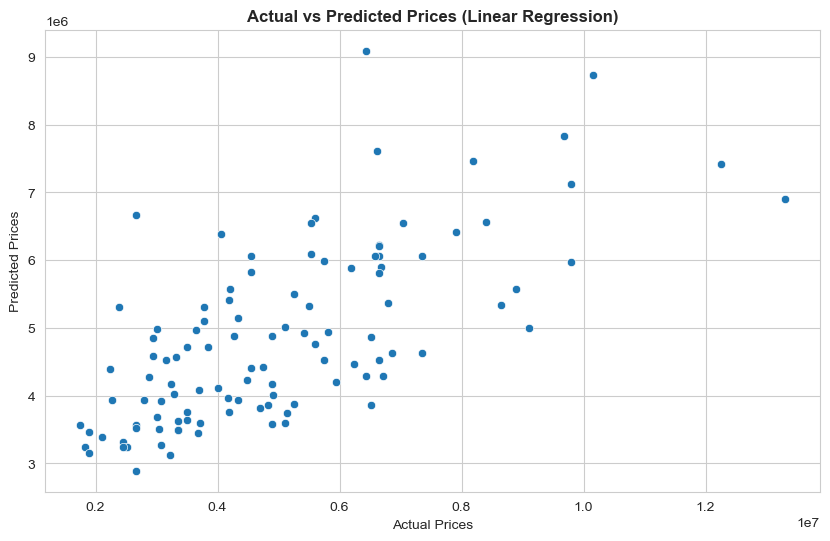

In [28]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test,y=y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices (Linear Regression)', weight='bold')
plt.show()

In [36]:
unseen_data=pd.DataFrame({'area': [1500],'bathrooms': [2],'bedrooms': [3]})
unseen_data

,area,bathrooms,bedrooms
0,1500,2,3


In [37]:
predicted_price=model.predict(unseen_data)

In [39]:
print(f'Predicted price for unseen data: {predicted_price[0]}')

Predicted price for unseen data: 4502917.500988724


In [30]:
x_test

,area,bathrooms,bedrooms
316,5900,2,4
77,6500,2,3
360,4040,1,2
90,5000,1,3
493,3960,1,3
...,...,...,...
15,6000,1,4
357,6930,1,4
39,6000,2,4
54,6000,2,3


In [31]:
y_test

316    4060000
77     6650000
360    3710000
90     6440000
493    2800000
        ...   
15     9100000
357    3773000
39     7910000
54     7350000
155    5530000
Name: price, Length: 109, dtype: int64

In [32]:
x_train

,area,bathrooms,bedrooms
46,6000,2,3
93,7200,2,3
335,3816,1,2
412,2610,1,3
471,3750,1,3
...,...,...,...
71,6000,2,4
106,5450,2,4
270,4500,2,3
435,4040,1,2


In [33]:
y_train

46     7525000
93     6300000
335    3920000
412    3430000
471    3010000
        ...   
71     6755000
106    6160000
270    4340000
435    3290000
102    6195000
Name: price, Length: 436, dtype: int64